In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.swa_utils import AveragedModel

## Configuration

In [2]:
# ── Chemins ─────────────────────────────────────────────────────────────────
CSV_PATH = "../data/dataset_selection.csv"

MODEL_PATHS = {
    "ConvNeXt-Small SWA": "convnext/convnext_swa_averaged.pth",
    "DenseNet-169":       "densenet/densenet169.pth",
    "EfficientNetV2-S":   "efficientnet/efficientnetv2s.pth",
    "ResNet-18":          "resnet/resnet18_best.pth",
}

# Poids d'ensemble proportionnels aux accuracies individuelles (test set sans TTA)
MODEL_WEIGHTS = {
    "ConvNeXt-Small SWA": 0.8718,
    "DenseNet-169":       0.8692,
    "EfficientNetV2-S":   0.8564,
    "ResNet-18":          0.8526,
}

# ── TTA ─────────────────────────────────────────────────────────────────────
N_TTA = 5        # nombre de passes TTA (1 = pas de TTA, 5 = recommandé)
IMG_SIZE = 224
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

for name, path in MODEL_PATHS.items():
    status = "✓" if os.path.exists(path) else "✗ MANQUANT"
    print(f"  {status}  {name} → {path}")

Device: cuda
  ✓  ConvNeXt-Small SWA → convnext/convnext_swa_averaged.pth
  ✓  DenseNet-169 → densenet/densenet169.pth
  ✓  EfficientNetV2-S → efficientnet/efficientnetv2s.pth
  ✓  ResNet-18 → resnet/resnet18_best.pth


## Données — même split que l'entraînement

In [3]:
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)
df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)

le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
CLASS_NAMES = list(le.classes_)
print("Classes:", CLASS_NAMES)

# Split identique à tous les notebooks d'entraînement (random_state=42)
_, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["y"])
test_df, _ = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["y"])
test_df = test_df.reset_index(drop=True)

print(f"Test set : {len(test_df)} images ({len(test_df)//num_classes} par classe)")

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Test set : 780 images (195 par classe)


## Utilitaires — crop, Dataset

In [4]:
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    arr = np.array(img)
    mask = arr.mean(axis=2) > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0 = max(0, ys.min() - pad);  y1 = min(arr.shape[0] - 1, ys.max() + pad)
    x0 = max(0, xs.min() - pad);  x1 = min(arr.shape[1] - 1, xs.max() + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))


class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.do_crop:
            img = crop_black_border_pil(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row["y"])

## Transforms TTA

5 passes identiques aux augmentations d'entraînement : original, H-flip, V-flip, rotation +15°, ColorJitter (brightness/contrast/saturation).

In [5]:
_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

TTA_TRANSFORMS = [
    # 1 — original
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(), _norm,
    ]),
    # 2 — flip horizontal (p=0.5 à l'entraînement)
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(), _norm,
    ]),
    # 3 — flip vertical (p=0.2 à l'entraînement)
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(), _norm,
    ]),
    # 4 — ColorJitter identique à l'entraînement
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
        transforms.ToTensor(), _norm,
    ]),
    # 5 — rotation +15° (degrees=15 à l'entraînement)
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(15, 15)),
        transforms.ToTensor(), _norm,
    ]),
]

print(f"{N_TTA} passes TTA configurées")

5 passes TTA configurées


## Fonction de prédiction TTA

In [6]:
def predict_tta(model, dataframe, device, n_tta=N_TTA):
    """Retourne (y_true, y_pred, proba_array) avec moyenne sur n_tta passes."""
    model.eval()
    all_probs = []

    for tfm in TTA_TRANSFORMS[:n_tta]:
        ds = FundusDataset(dataframe, transform=tfm, do_crop=True)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)
        pass_probs = []
        with torch.no_grad():
            for x, _ in loader:
                probs = torch.softmax(model(x.to(device)), dim=1)
                pass_probs.append(probs.cpu().numpy())
        all_probs.append(np.concatenate(pass_probs, axis=0))

    proba = np.mean(all_probs, axis=0)
    y_true = dataframe["y"].values
    y_pred = proba.argmax(axis=1)
    return y_true, y_pred, proba


def plot_cm(cm, class_names, title="Confusion Matrix"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, fmt, t in zip(axes, [cm, cm_norm], ["d", ".2f"],
                                 [title, title + " (normalisée)"]):
        im = ax.imshow(data, cmap="Blues")
        ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
        ax.set_xlabel("Prédit"); ax.set_ylabel("Vrai"); ax.set_title(t)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = data[i, j]
                ax.text(j, i, f"{val:.2f}" if fmt == ".2f" else str(val),
                        ha="center", va="center",
                        color="white" if val > data.max() * 0.6 else "black")
    plt.tight_layout(); plt.show()

## Chargement des 4 modèles

In [7]:
# ── ConvNeXt-Small + SWA ─────────────────────────────────────────────────────
_base_small = models.convnext_small(weights=None)
_base_small.classifier[2] = nn.Linear(_base_small.classifier[2].in_features, num_classes)
model_convnext_small = AveragedModel(_base_small)
model_convnext_small.load_state_dict(
    torch.load(MODEL_PATHS["ConvNeXt-Small SWA"], map_location=device, weights_only=True))
model_convnext_small = model_convnext_small.to(device).eval()
print("✓ ConvNeXt-Small SWA chargé")

# ── DenseNet-169 ─────────────────────────────────────────────────────────────
model_densenet = models.densenet169(weights=None)
model_densenet.classifier = nn.Linear(model_densenet.classifier.in_features, num_classes)
model_densenet.load_state_dict(
    torch.load(MODEL_PATHS["DenseNet-169"], map_location=device, weights_only=True))
model_densenet = model_densenet.to(device).eval()
print("✓ DenseNet-169 chargé")

# ── EfficientNetV2-S ─────────────────────────────────────────────────────────
model_efficientnet = models.efficientnet_v2_s(weights=None)
model_efficientnet.classifier[1] = nn.Linear(model_efficientnet.classifier[1].in_features, num_classes)
model_efficientnet.load_state_dict(
    torch.load(MODEL_PATHS["EfficientNetV2-S"], map_location=device, weights_only=True))
model_efficientnet = model_efficientnet.to(device).eval()
print("✓ EfficientNetV2-S chargé")

# ── ResNet-18 ────────────────────────────────────────────────────────────────
model_resnet = models.resnet18(weights=None)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, num_classes)
model_resnet.load_state_dict(
    torch.load(MODEL_PATHS["ResNet-18"], map_location=device, weights_only=True))
model_resnet = model_resnet.to(device).eval()
print("✓ ResNet-18 chargé")

✓ ConvNeXt-Small SWA chargé
✓ DenseNet-169 chargé
✓ EfficientNetV2-S chargé
✓ ResNet-18 chargé


## Évaluation individuelle — sans TTA vs TTA


  ConvNeXt-Small SWA

[Sans TTA]  Accuracy : 0.8718   |   AUC-ROC : 0.9585
[TTA x5]   Accuracy : 0.8667   |   AUC-ROC : 0.9612   (Δ -0.0051)
              precision    recall  f1-score   support

     diabete     0.8146    0.8564    0.8350       195
    glaucome     0.9541    0.9590    0.9565       195
         mda     0.9254    0.9538    0.9394       195
     normaux     0.7640    0.6974    0.7292       195

    accuracy                         0.8667       780
   macro avg     0.8645    0.8667    0.8650       780
weighted avg     0.8645    0.8667    0.8650       780



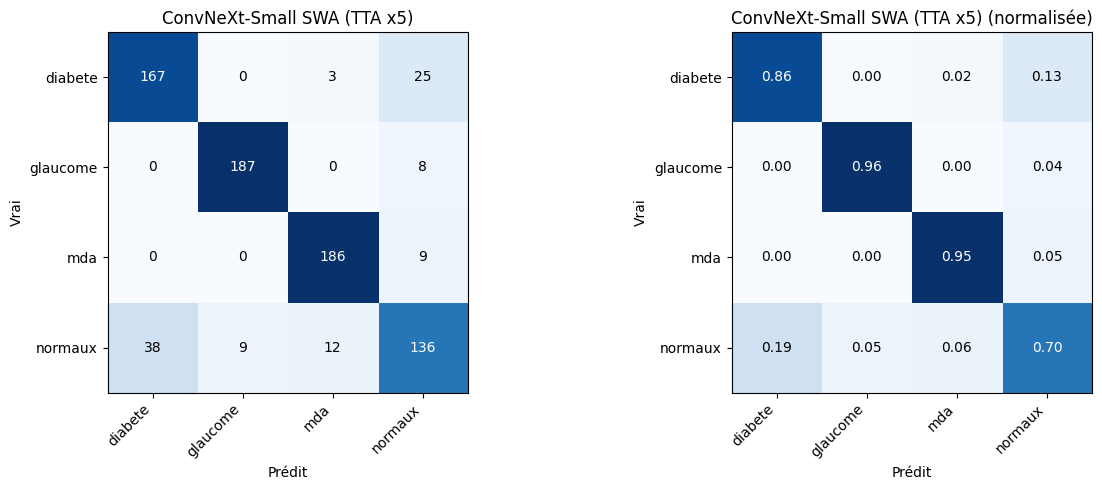


  DenseNet-169

[Sans TTA]  Accuracy : 0.8692   |   AUC-ROC : 0.9654
[TTA x5]   Accuracy : 0.8731   |   AUC-ROC : 0.9658   (Δ +0.0038)
              precision    recall  f1-score   support

     diabete     0.7972    0.8872    0.8398       195
    glaucome     0.9497    0.9692    0.9594       195
         mda     0.9444    0.9590    0.9517       195
     normaux     0.7952    0.6769    0.7313       195

    accuracy                         0.8731       780
   macro avg     0.8717    0.8731    0.8705       780
weighted avg     0.8717    0.8731    0.8705       780



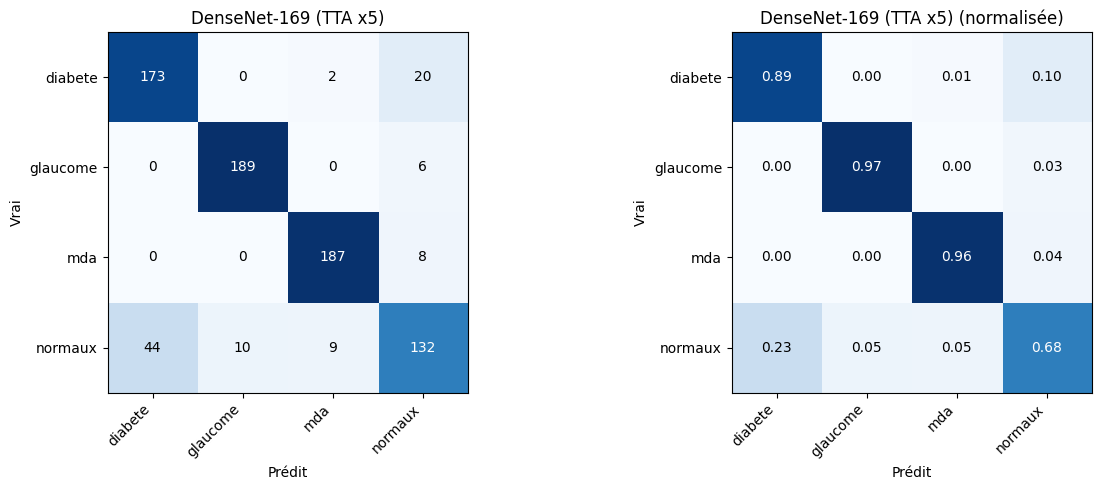


  EfficientNetV2-S

[Sans TTA]  Accuracy : 0.8564   |   AUC-ROC : 0.9583
[TTA x5]   Accuracy : 0.8603   |   AUC-ROC : 0.9607   (Δ +0.0038)
              precision    recall  f1-score   support

     diabete     0.7980    0.8103    0.8041       195
    glaucome     0.9543    0.9641    0.9592       195
         mda     0.9231    0.9846    0.9529       195
     normaux     0.7514    0.6821    0.7151       195

    accuracy                         0.8603       780
   macro avg     0.8567    0.8603    0.8578       780
weighted avg     0.8567    0.8603    0.8578       780



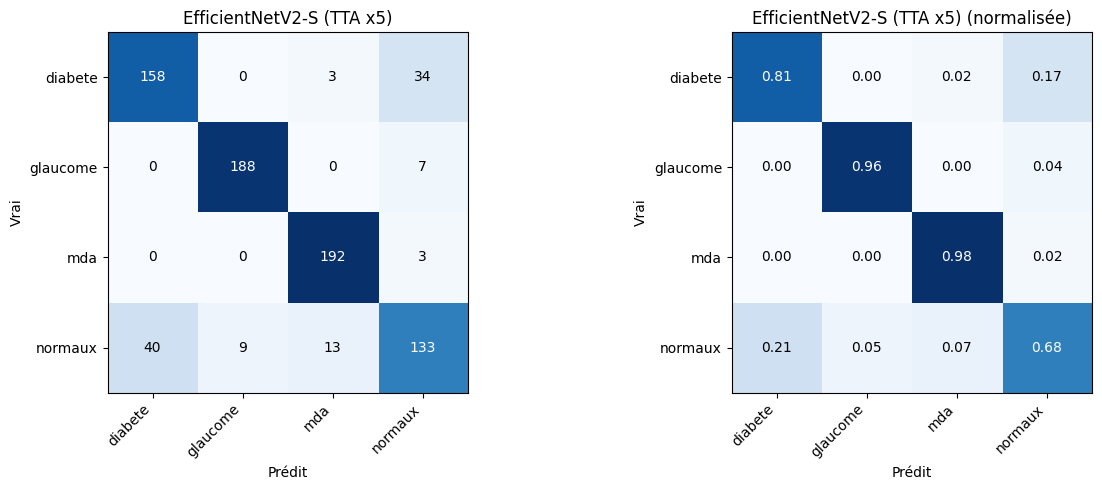


  ResNet-18

[Sans TTA]  Accuracy : 0.8526   |   AUC-ROC : 0.9589
[TTA x5]   Accuracy : 0.8564   |   AUC-ROC : 0.9605   (Δ +0.0038)
              precision    recall  f1-score   support

     diabete     0.7598    0.8923    0.8208       195
    glaucome     0.9785    0.9333    0.9554       195
         mda     0.9307    0.9641    0.9471       195
     normaux     0.7607    0.6359    0.6927       195

    accuracy                         0.8564       780
   macro avg     0.8574    0.8564    0.8540       780
weighted avg     0.8574    0.8564    0.8540       780



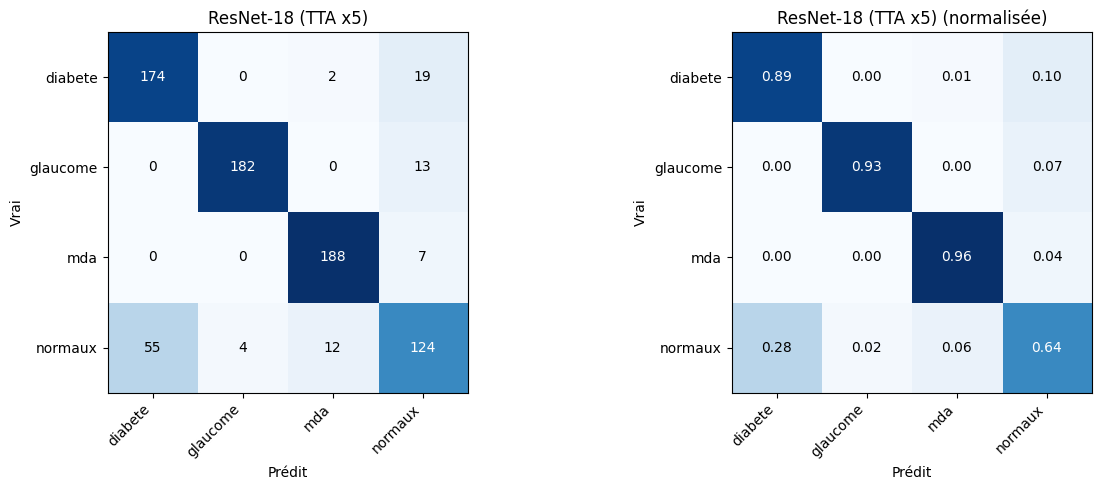

In [8]:
loaded_models = {
    "ConvNeXt-Small SWA": model_convnext_small,
    "DenseNet-169":       model_densenet,
    "EfficientNetV2-S":   model_efficientnet,
    "ResNet-18":          model_resnet,
}

results        = {}  # avec TTA
results_no_tta = {}  # sans TTA

for name, model in loaded_models.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    # ── Sans TTA ──────────────────────────────────────────────
    y_true, y_pred, proba = predict_tta(model, test_df, device, n_tta=1)
    results_no_tta[name] = (y_true, y_pred, proba)
    acc_no = (y_true == y_pred).mean()
    auc_no = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    print(f"\n[Sans TTA]  Accuracy : {acc_no:.4f}   |   AUC-ROC : {auc_no:.4f}")

    # ── Avec TTA ──────────────────────────────────────────────
    y_true, y_pred, proba = predict_tta(model, test_df, device, n_tta=N_TTA)
    results[name] = (y_true, y_pred, proba)
    acc_ta = (y_true == y_pred).mean()
    auc_ta = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    print(f"[TTA x{N_TTA}]   Accuracy : {acc_ta:.4f}   |   AUC-ROC : {auc_ta:.4f}   (Δ {acc_ta - acc_no:+.4f})")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    plot_cm(confusion_matrix(y_true, y_pred), CLASS_NAMES, title=f"{name} (TTA x{N_TTA})")

## Ensemble pondéré (soft voting) — sans TTA vs TTA

  ENSEMBLE sans TTA

Accuracy : 0.8667   |   AUC-ROC macro : 0.9672
              precision    recall  f1-score   support

     diabete     0.7783    0.8821    0.8269       195
    glaucome     0.9590    0.9590    0.9590       195
         mda     0.9356    0.9692    0.9521       195
     normaux     0.7901    0.6564    0.7171       195

    accuracy                         0.8667       780
   macro avg     0.8658    0.8667    0.8638       780
weighted avg     0.8658    0.8667    0.8638       780



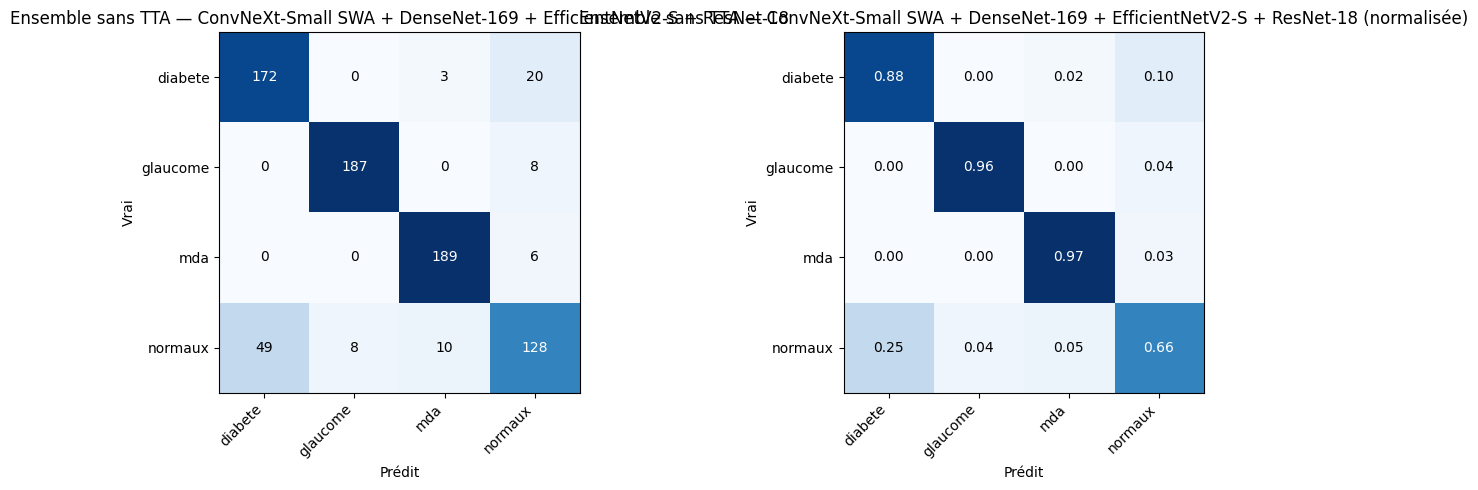

  ENSEMBLE avec TTA x5

Accuracy : 0.8679   |   AUC-ROC macro : 0.9672
              precision    recall  f1-score   support

     diabete     0.7848    0.8974    0.8373       195
    glaucome     0.9590    0.9590    0.9590       195
         mda     0.9265    0.9692    0.9474       195
     normaux     0.7975    0.6462    0.7139       195

    accuracy                         0.8679       780
   macro avg     0.8669    0.8679    0.8644       780
weighted avg     0.8669    0.8679    0.8644       780



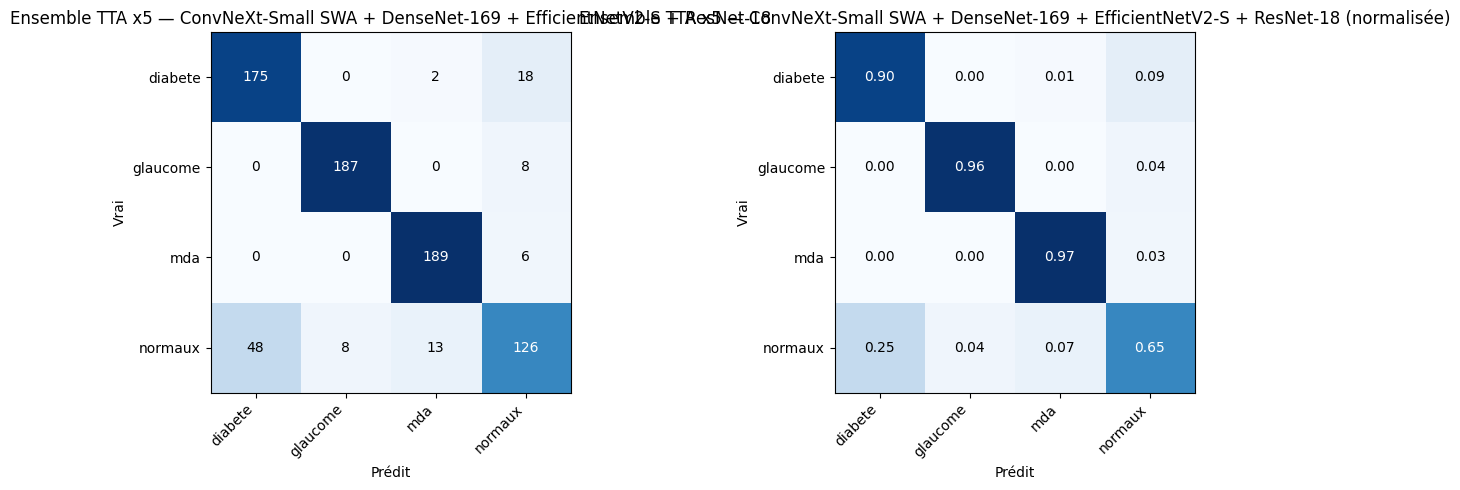

In [9]:
total_weight = sum(MODEL_WEIGHTS[n] for n in loaded_models)
y_true_ens = results["ConvNeXt-Small SWA"][0]

# ── Ensemble sans TTA ────────────────────────────────────────────────────────
ensemble_proba_no_tta = sum(
    (MODEL_WEIGHTS[name] / total_weight) * results_no_tta[name][2]
    for name in loaded_models
)
y_pred_ens_no_tta = ensemble_proba_no_tta.argmax(axis=1)
acc_ens_no_tta = (y_true_ens == y_pred_ens_no_tta).mean()
auc_ens_no_tta = roc_auc_score(y_true_ens, ensemble_proba_no_tta, multi_class="ovr", average="macro")

print(f"{'='*60}")
print(f"  ENSEMBLE sans TTA")
print(f"{'='*60}")
print(f"\nAccuracy : {acc_ens_no_tta:.4f}   |   AUC-ROC macro : {auc_ens_no_tta:.4f}")
print(classification_report(y_true_ens, y_pred_ens_no_tta, target_names=CLASS_NAMES, digits=4))
plot_cm(confusion_matrix(y_true_ens, y_pred_ens_no_tta), CLASS_NAMES,
        title="Ensemble sans TTA — ConvNeXt-Small SWA + DenseNet-169 + EfficientNetV2-S + ResNet-18")

# ── Ensemble avec TTA ────────────────────────────────────────────────────────
ensemble_proba = sum(
    (MODEL_WEIGHTS[name] / total_weight) * results[name][2]
    for name in loaded_models
)
y_pred_ens = ensemble_proba.argmax(axis=1)
acc_ens = (y_true_ens == y_pred_ens).mean()
auc_ens = roc_auc_score(y_true_ens, ensemble_proba, multi_class="ovr", average="macro")

print(f"{'='*60}")
print(f"  ENSEMBLE avec TTA x{N_TTA}")
print(f"{'='*60}")
print(f"\nAccuracy : {acc_ens:.4f}   |   AUC-ROC macro : {auc_ens:.4f}")
print(classification_report(y_true_ens, y_pred_ens, target_names=CLASS_NAMES, digits=4))
plot_cm(confusion_matrix(y_true_ens, y_pred_ens), CLASS_NAMES,
        title=f"Ensemble TTA x{N_TTA} — ConvNeXt-Small SWA + DenseNet-169 + EfficientNetV2-S + ResNet-18")

## Images mal classées par l'ensemble (TTA)

Images mal classées (ensemble TTA x5) : 103 / 780
Accuracy ensemble : 0.8679

  diabete      :  20 erreurs / 195  (10.3% d'erreur)
  glaucome     :   8 erreurs / 195  (4.1% d'erreur)
  mda          :   6 erreurs / 195  (3.1% d'erreur)
  normaux      :  69 erreurs / 195  (35.4% d'erreur)


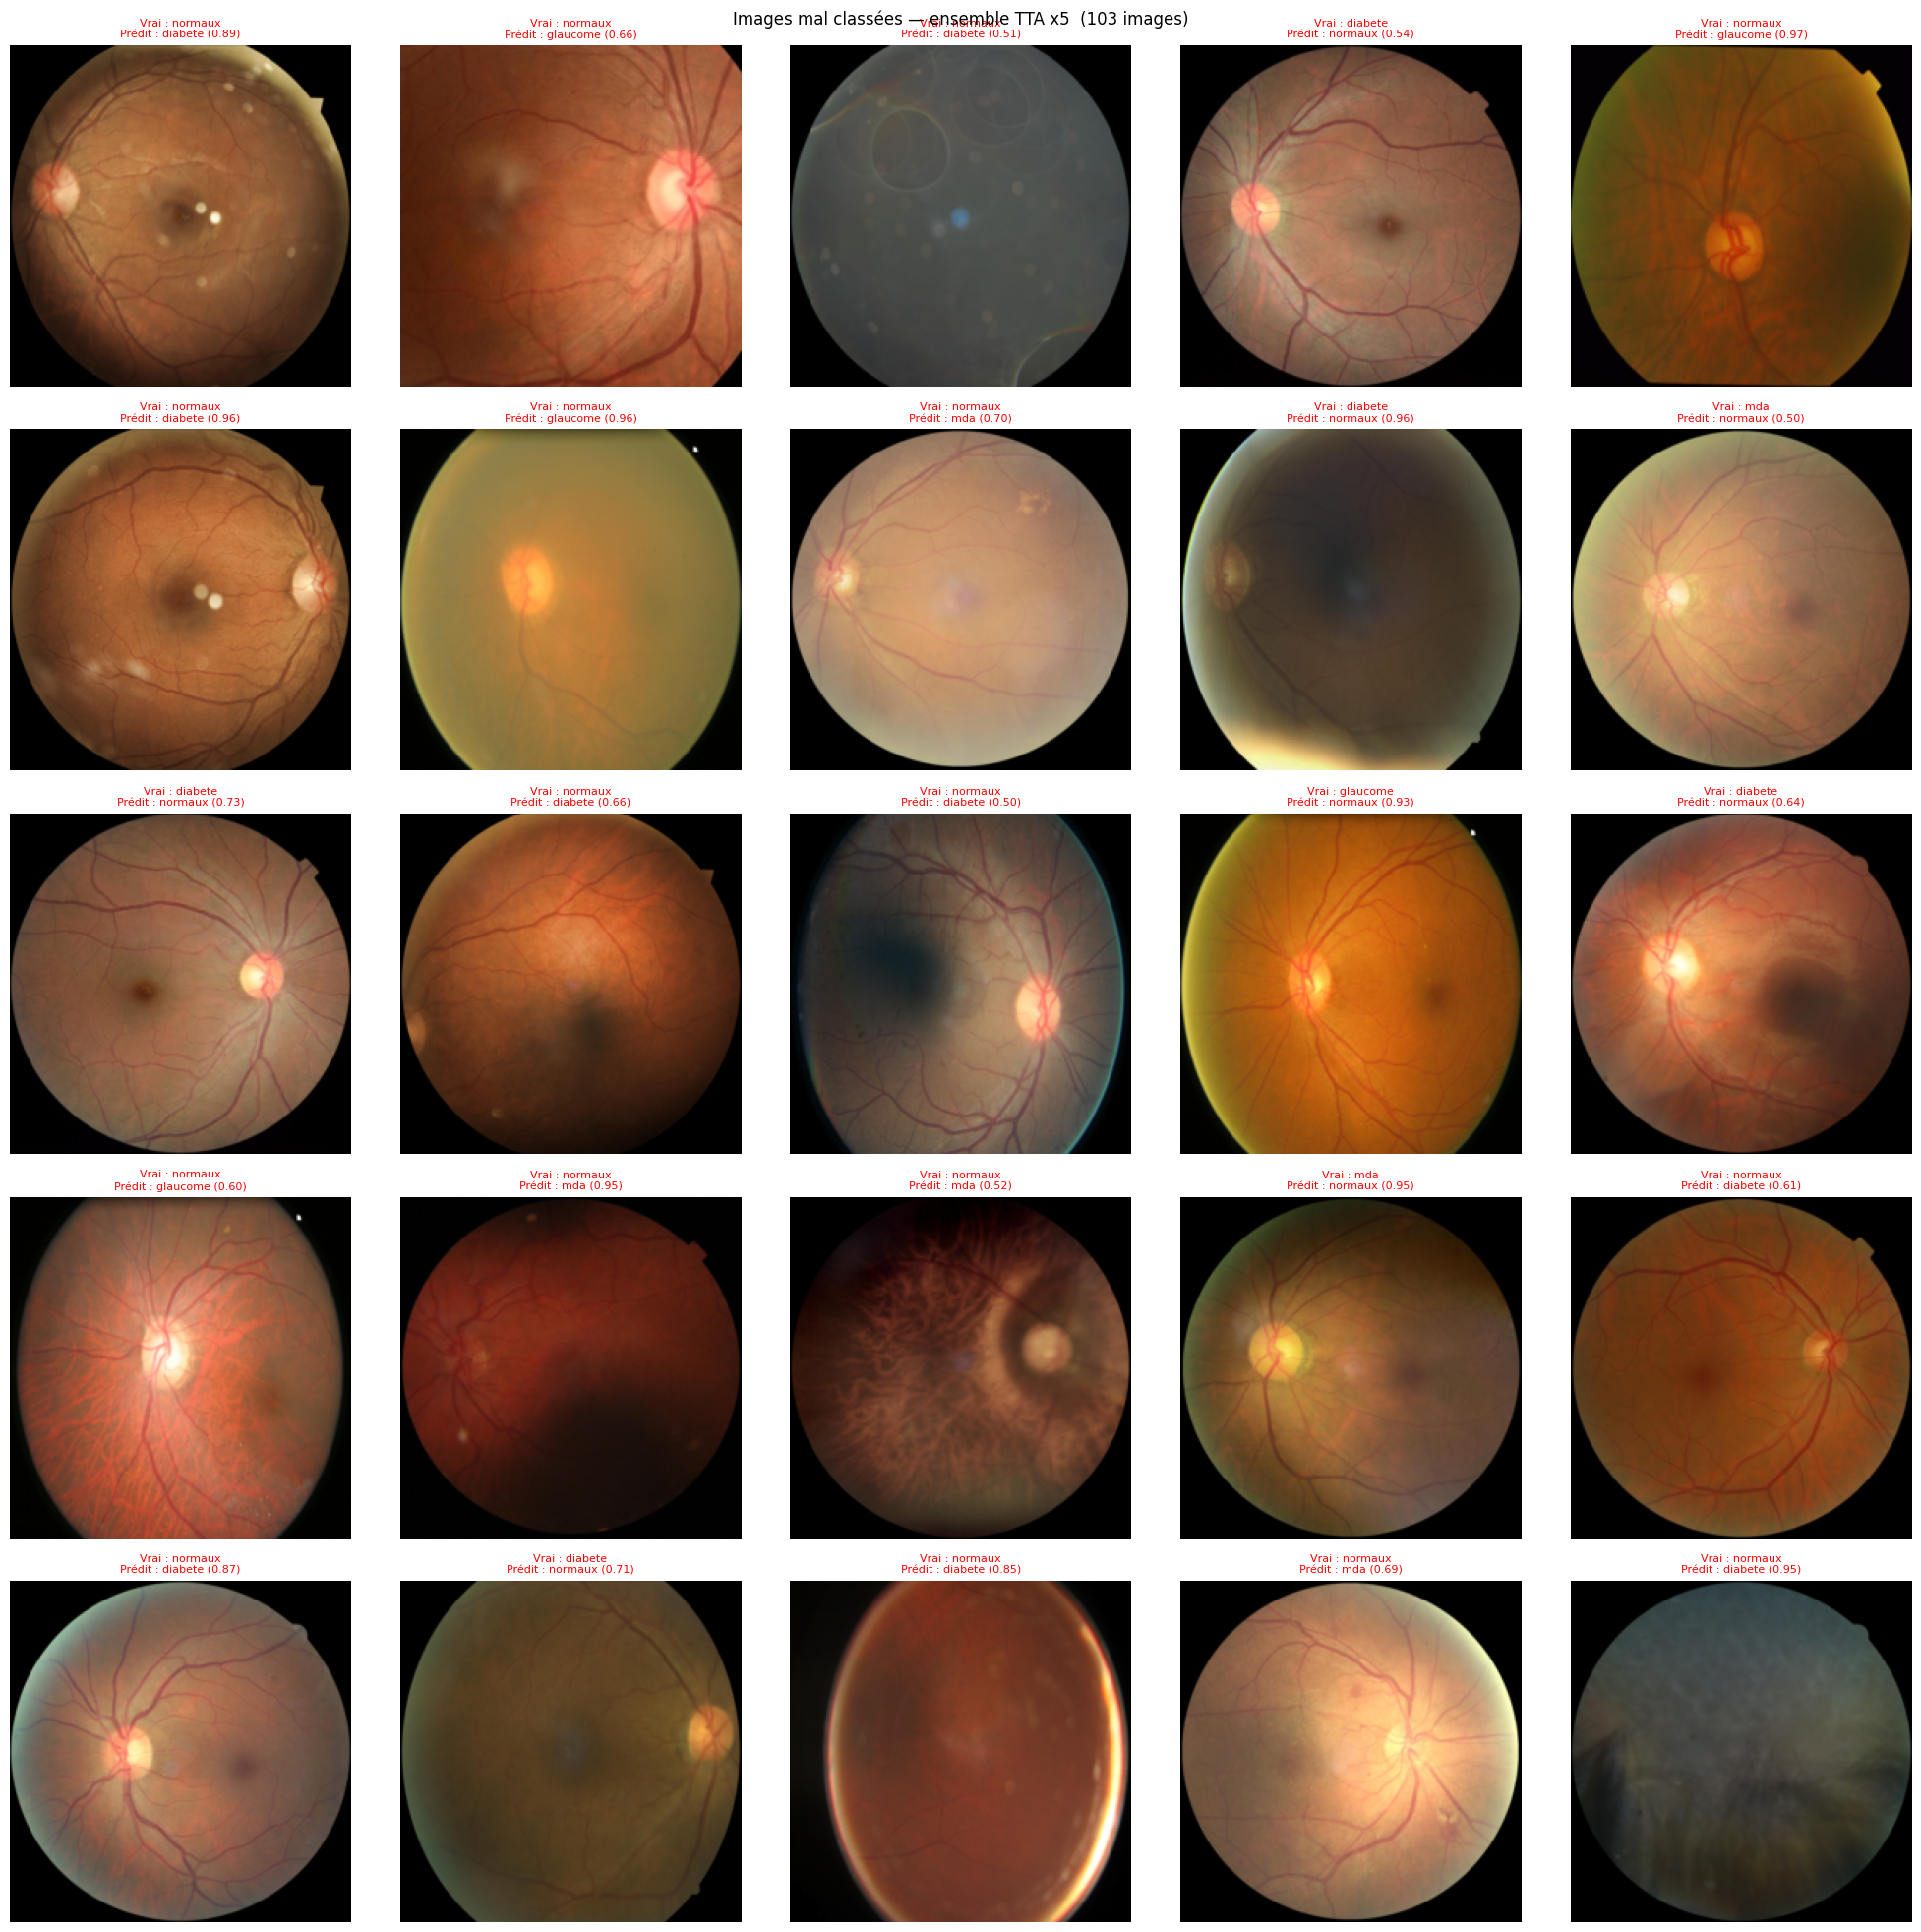

In [10]:
misclassified_idx = np.where(y_true_ens != y_pred_ens)[0]
print(f"Images mal classées (ensemble TTA x{N_TTA}) : {len(misclassified_idx)} / {len(test_df)}")
print(f"Accuracy ensemble : {1 - len(misclassified_idx)/len(test_df):.4f}\n")

for cls in CLASS_NAMES:
    cls_idx = int(le.transform([cls])[0])
    cls_mask = (y_true_ens == cls_idx)
    wrong = ((y_true_ens != y_pred_ens) & cls_mask).sum()
    total = cls_mask.sum()
    print(f"  {cls:<12} : {wrong:>3} erreurs / {total}  ({wrong/total*100:.1f}% d'erreur)")

val_tfm = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

n_show = min(len(misclassified_idx), 25)
n_cols = 5
n_rows = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, idx in enumerate(misclassified_idx[:n_show]):
    row = test_df.iloc[idx]
    img = crop_black_border_pil(Image.open(row["path"]).convert("RGB"))
    axes[i].imshow(val_tfm(img).permute(1, 2, 0).numpy())
    true_lbl  = CLASS_NAMES[int(row["y"])]
    pred_lbl  = CLASS_NAMES[y_pred_ens[idx]]
    conf      = ensemble_proba[idx, y_pred_ens[idx]]
    axes[i].set_title(f"Vrai : {true_lbl}\nPrédit : {pred_lbl} ({conf:.2f})", fontsize=8, color="red")
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Images mal classées — ensemble TTA x{N_TTA}  ({len(misclassified_idx)} images)", fontsize=12)
plt.tight_layout()
plt.show()

## Récapitulatif

In [11]:
print(f"{'Modèle':<30} {'Sans TTA':<12} {'TTA x'+str(N_TTA):<12} {'\u0394 TTA':<10} {'AUC (TTA)'}")
print("-" * 80)

for name in loaded_models:
    yt_no, yp_no, p_no = results_no_tta[name]
    yt, yp, p = results[name]
    acc_no = (yt_no == yp_no).mean()
    acc_ta = (yt == yp).mean()
    auc_ta = roc_auc_score(yt, p, multi_class="ovr", average="macro")
    delta = acc_ta - acc_no
    sign = "+" if delta >= 0 else ""
    print(f"{name:<30} {acc_no:<12.4f} {acc_ta:<12.4f} {sign}{delta:<9.4f} {auc_ta:.4f}")

print("-" * 80)
delta_ens = acc_ens - acc_ens_no_tta
sign = "+" if delta_ens >= 0 else ""
print(f"{'ENSEMBLE':<30} {acc_ens_no_tta:<12.4f} {acc_ens:<12.4f} {sign}{delta_ens:<9.4f} {auc_ens:.4f}")

Modèle                         Sans TTA     TTA x5       Δ TTA      AUC (TTA)
--------------------------------------------------------------------------------
ConvNeXt-Small SWA             0.8718       0.8667       -0.0051   0.9612
DenseNet-169                   0.8692       0.8731       +0.0038    0.9658
EfficientNetV2-S               0.8564       0.8603       +0.0038    0.9607
ResNet-18                      0.8526       0.8564       +0.0038    0.9605
--------------------------------------------------------------------------------
ENSEMBLE                       0.8667       0.8679       +0.0013    0.9672
